In [1]:
import os
from datasets import load_dataset
import pandas as pd

CACHE_PATH = "../data/raw/cache.csv"

In [ ]:
df = pd.read_csv(CACHE_PATH)
df

,uid,timestamp,item_id,is_organic,played_ratio_pct,track_length_seconds,event_type
0,1,20955160,821534,1,0.0,165.0,listen
1,1,20955585,3506815,1,27.0,150.0,listen
2,1,20955725,798711,1,31.0,125.0,listen
3,1,20955835,5302349,1,97.0,110.0,listen
4,1,20955985,6317616,1,100.0,145.0,listen
...,...,...,...,...,...,...,...
45854,11,13008560,3690287,0,100.0,195.0,listen
45855,11,13008720,7964514,0,100.0,160.0,listen
45856,11,13008950,7930786,0,100.0,230.0,listen
45857,11,13009160,6254101,0,100.0,205.0,listen


In [4]:
df.event_type.value_counts()

event_type
listen    45859
Name: count, dtype: int64

In [6]:
df.uid.value_counts()

uid
3     16788
6      8194
8      6340
5      5996
11     4428
10     2123
7      1171
1       674
9       108
2        37
Name: count, dtype: int64

In [7]:
df.item_id.value_counts()

item_id
4623471    130
5693518    120
1970200    109
5077944    106
1454485    105
          ... 
289995       1
7152289      1
4359061      1
8610451      1
1887550      1
Name: count, Length: 11157, dtype: int64

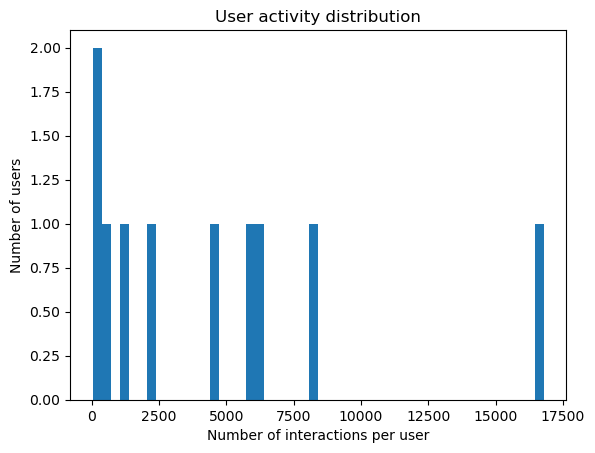

In [8]:
import matplotlib.pyplot as plt

user_activity = df.groupby("uid").size()

plt.hist(user_activity, bins=50)
plt.title("User activity distribution")
plt.xlabel("Number of interactions per user")
plt.ylabel("Number of users")
plt.show()

In [9]:
n_users = df.uid.nunique()
n_items = df.item_id.nunique()

sparsity = 1 - len(df) / (n_users * n_items)

print("Users:", n_users)
print("Items:", n_items)
print("Sparsity:", sparsity)

Users: 10
Items: 11157
Sparsity: 0.588966568073855


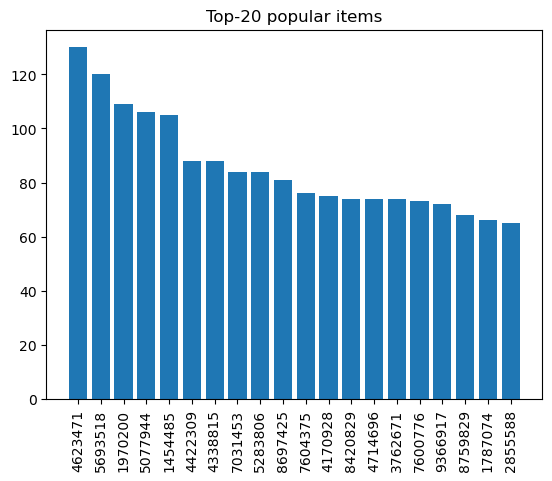

In [10]:
top_items = df.item_id.value_counts().head(20)

plt.bar(top_items.index.astype(str), top_items.values)
plt.xticks(rotation=90)
plt.title("Top-20 popular items")
plt.show()

In [11]:
session_lengths = df.groupby("uid").size()

session_lengths.describe()

count       10.000000
mean      4585.900000
std       5172.300916
min         37.000000
25%        798.250000
50%       3275.500000
75%       6254.000000
max      16788.000000
dtype: float64

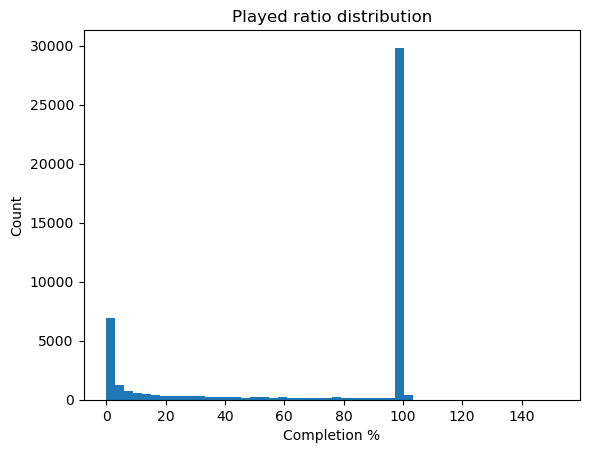

In [13]:
plt.hist(df["played_ratio_pct"], bins=50)
plt.title("Played ratio distribution")
plt.xlabel("Completion %")
plt.ylabel("Count")
plt.show()

In [12]:
df.groupby("is_organic")["played_ratio_pct"].mean()

is_organic
0    73.887849
1    71.311617
Name: played_ratio_pct, dtype: float64